<a href="https://colab.research.google.com/github/pravee827/AI-ML/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 54

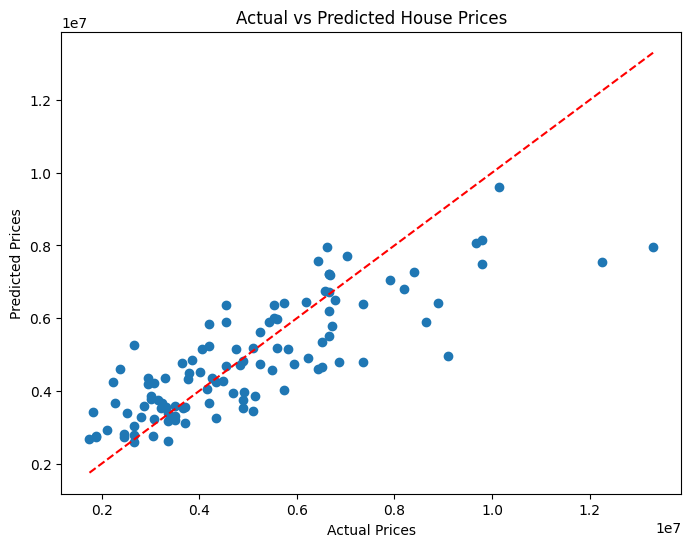

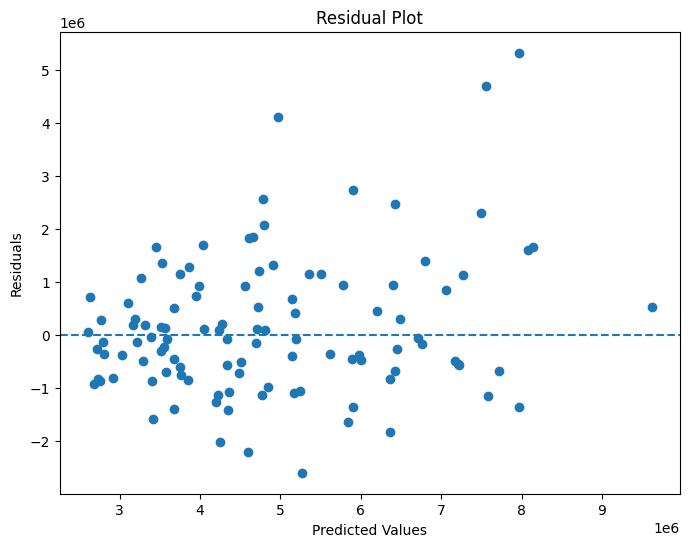

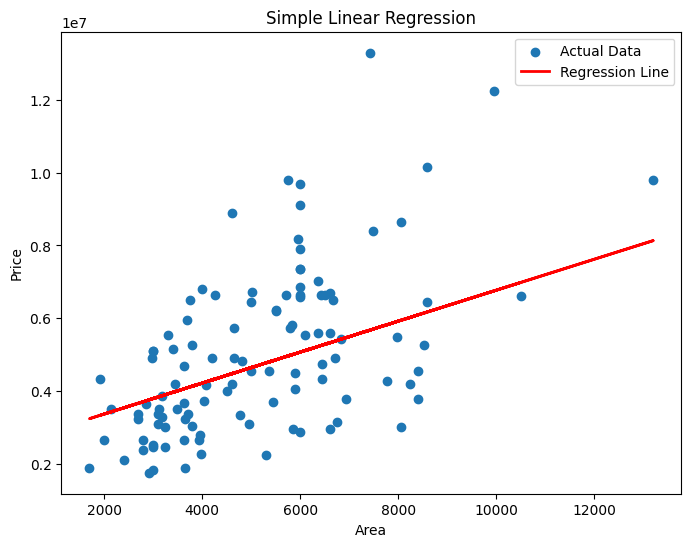


Simple Regression Coefficient: 425.72984193878284
Simple Regression Intercept: 2512254.2639593435

Task Completed Successfully!


In [1]:
# TASK 3: LINEAR REGRESSION
# AI & ML INTERNSHIP
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================
# Load Dataset
# ============================================

# Replace with your dataset path
df = pd.read_csv("Housing.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================
# Data Preprocessing
# ============================================

# Convert categorical columns to numerical
categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# ============================================
# Define Features and Target
# ============================================

X = df.drop("price", axis=1)
y = df["price"]

# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================
# Build Linear Regression Model
# ============================================

model = LinearRegression()

model.fit(X_train, y_train)

# ============================================
# Predictions
# ============================================

y_pred = model.predict(X_test)

# ============================================
# Evaluation Metrics
# ============================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("-" * 40)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

# ============================================
# Coefficients
# ============================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients:")
print(coefficients.sort_values(by="Coefficient", ascending=False))

# ============================================
# Actual vs Predicted Plot
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

# ============================================
# Residual Plot
# ============================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# ============================================
# Simple Linear Regression Example
# ============================================

# Using only area feature

if 'area' in df.columns:

    X_simple = df[['area']]
    y_simple = df['price']

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_simple,
        y_simple,
        test_size=0.2,
        random_state=42
    )

    simple_model = LinearRegression()

    simple_model.fit(X_train_s, y_train_s)

    y_pred_s = simple_model.predict(X_test_s)

    plt.figure(figsize=(8,6))

    plt.scatter(X_test_s, y_test_s, label="Actual Data")

    plt.plot(
        X_test_s,
        y_pred_s,
        color='red',
        linewidth=2,
        label="Regression Line"
    )

    plt.xlabel("Area")
    plt.ylabel("Price")
    plt.title("Simple Linear Regression")

    plt.legend()
    plt.show()

    print("\nSimple Regression Coefficient:",
          simple_model.coef_[0])

    print("Simple Regression Intercept:",
          simple_model.intercept_)

print("\nTask Completed Successfully!")